Notebook basado en el artículo [Iris Classification using a Keras Neural Network](https://medium.com/@manwill/iris-classification-using-a-keras-neural-network-39d735d11fda)


# Imports

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from keras.layers import *
from keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

# Load dataset

In [63]:
df = load_iris()

In [64]:
df['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

![SepalovsPetalo](https://upload.wikimedia.org/wikipedia/commons/c/c5/P%C3%A9talo-s%C3%A9palo.jpg)

Wikipedia

In [65]:
df['data']

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [66]:
df['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [67]:
df['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## One-hot encode target data

In [68]:
y = OneHotEncoder().fit_transform(df['target'].reshape(-1, 1)).toarray()

In [69]:
y

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

## Split data in train and test

In [70]:
X_train, X_test, y_train, y_test = train_test_split(df['data'], y, test_size=0.2, random_state=42)

In [71]:
print("Train X dataset shape: ", np.shape(X_train))
print("Train y dataset shape: ", np.shape(y_train))
print("Test X dataset shape: ", np.shape(X_test))
print("Test y dataset shape: ", np.shape(y_test))

Train X dataset shape:  (120, 4)
Train y dataset shape:  (120, 3)
Test X dataset shape:  (30, 4)
Test y dataset shape:  (30, 3)


# Model definition

- Define una entrada con la forma de input_len
- Capa oculta densa con 16 neuronas y relu
- Capa de salida con 1 neurona por cada clase
- Activación softmax

In [72]:
def create_classifier(input_len, output_len):

  entrada = Input(shape=(input_len,), name="entrada")

  x = Dense(16, activation="relu", name="capa_oculta")(entrada)

  salida = Dense(
      output_len,
      activation="softmax",
      name="capa_salida"
  )(x)
  return Model(inputs=entrada, outputs=salida)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta (Dense)             │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

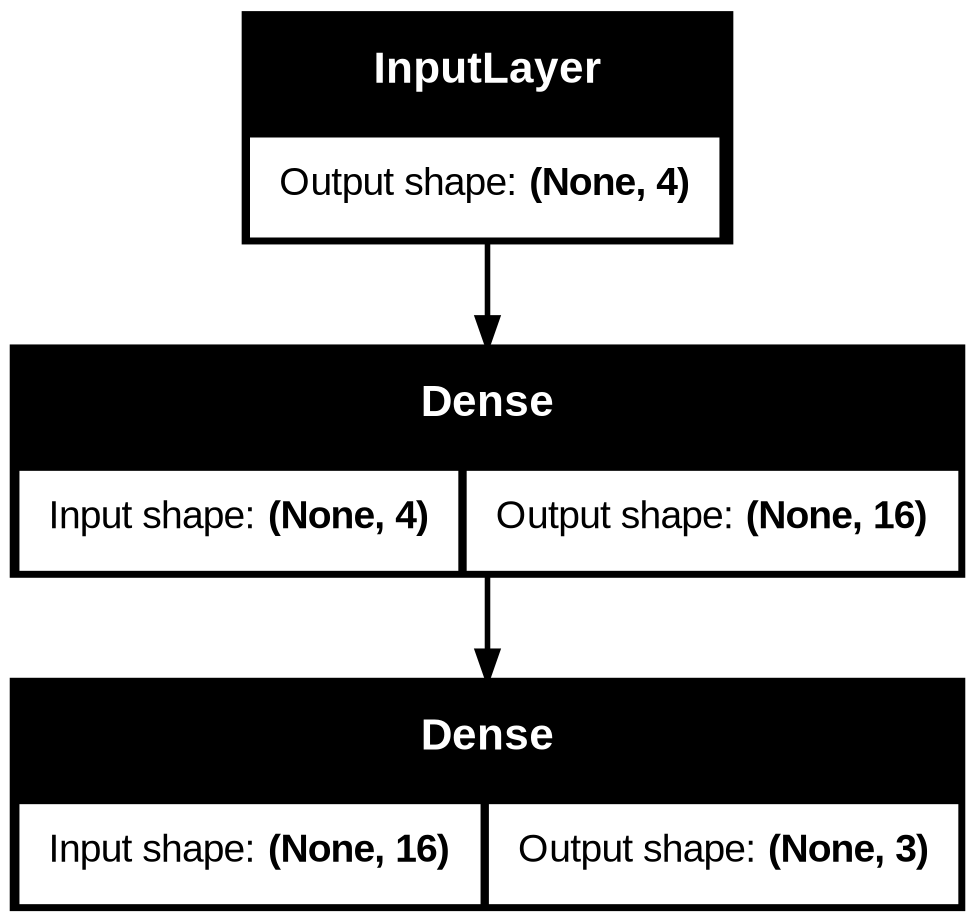

In [73]:
model = create_classifier(len(X_train[0]), len(y_train[0]))
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False)

- **`loss='categorical_crossentropy'`**  
  - Para clasificación multiclase con etiquetas **one-hot**.  
  - Calcula la entropía cruzada entre predicción (softmax) y la clase real.
  - Penaliza más cuando la red está muy segura pero se equivoca.

- **`metrics=['accuracy']`**  
  - Muestra la **exactitud**: proporción de predicciones correctas.  

- **`optimizer=Adam()`**  
  - Descenso de gradiente adaptativo.  
  - Combina Momentum y RMSProp.  
  - Parámetros por defecto suelen funcionar bien.

In [74]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer=Adam())

# Train model

In [75]:
history = model.fit(X_train[:], y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test), verbose=1)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.0000e+00 - loss: 1.5649 - val_accuracy: 0.0000e+00 - val_loss: 1.4466
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 1.4434 - val_accuracy: 0.0000e+00 - val_loss: 1.3591
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 1.3465 - val_accuracy: 0.0000e+00 - val_loss: 1.3006
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0833 - loss: 1.2910 - val_accuracy: 0.1333 - val_loss: 1.2596
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1583 - loss: 1.2502 - val_accuracy: 0.1333 - val_loss: 1.2290
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2000 - loss: 1.2154 - val_accuracy: 0.1667 - val_loss: 1.1972
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2333 - loss: 1.1864 - val_accuracy: 0.1667 - val_loss: 1.1675
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2500 - loss: 1.1583 - val_accuracy: 0

# Evaluate the model

In [76]:
def plot_losses(history):
    plt.rcParams['figure.figsize'] = [20, 5]
    f, (ax1, ax2) = plt.subplots(1, 2, sharex=True)

    ax1.set_title('Losses')
    ax1.set_xlabel('epoch')
    ax1.legend(loc="upper right")
    ax1.grid()
    ax1.plot(history['loss'], label='Training loss')
    ax1.plot(history['val_loss'], label='Validation loss')
    ax1.legend()

    ax2.set_title('Accuracy')
    ax2.set_xlabel('epoch')
    ax2.legend(loc="upper right")
    ax2.grid()
    ax2.plot(history['accuracy'], label='Training accuracy')
    ax2.plot(history['val_accuracy'], label='Validation accuracy')
    ax2.legend()

    plt.show()

/tmp/ipykernel_793/217370305.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper right")
/tmp/ipykernel_793/217370305.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right")


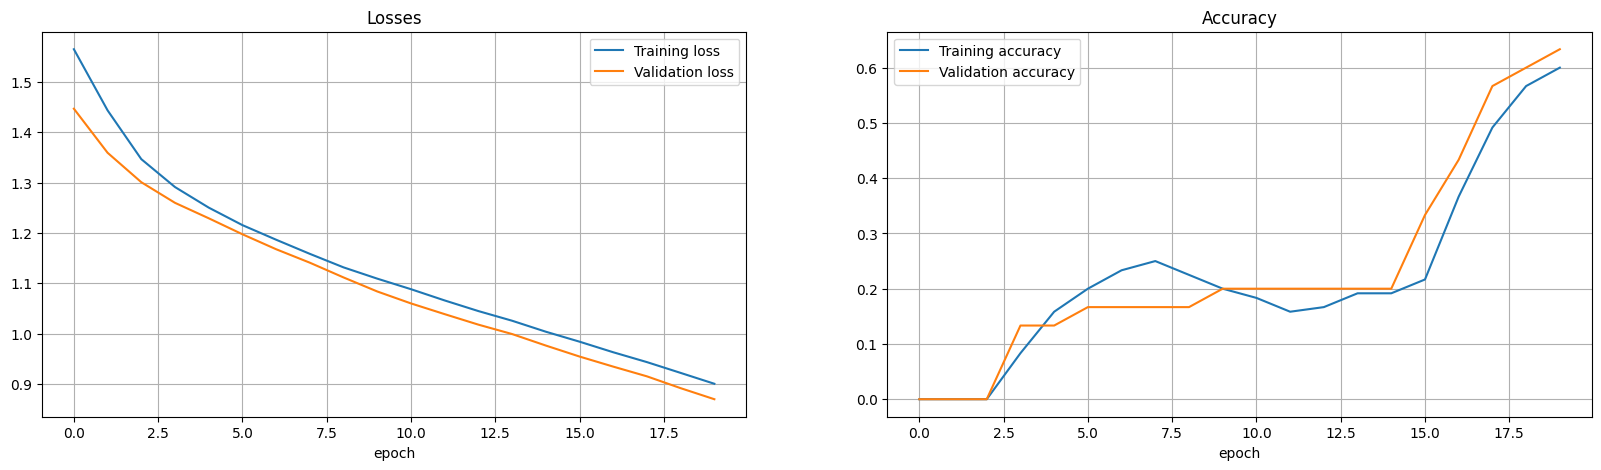

In [77]:
plot_losses(history.history)

In [78]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_test = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_test, y_pred)
cm

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


array([[10,  0,  0],
       [ 0,  3,  6],
       [ 0,  5,  6]])

---

Creado por **Guillermo Iglesias** (guillermo.iglesias@upm.es)

Ampliado por **Jorge Dueñas Lerín** (jorge.duenas.lerin@upm.es)

<img src="https://licensebuttons.net/l/by-nc-sa/3.0/88x31.png">